<style>
.reveal { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 1.05em; }
.reveal h2 { color: #0D2240; border-bottom: 2.5px solid #1A7A9A; padding-bottom: .3em; }
.reveal h3 { color: #1A7A9A; }
.reveal .slides section { text-align: left; }
.reveal pre { font-size: .75em; box-shadow: none; border-left: 3px solid #1A7A9A; }
.defn { background:#EAF6FA; border-left:4px solid #1A7A9A; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.nota { background:#FFF8E1; border-left:4px solid #C8961E; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.alerta { background:#FDE8E8; border-left:4px solid #C0392B; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
.resultado { background:#F0FFF4; border-left:4px solid #2E7D32; padding:.6em 1em; margin:.5em 0; border-radius:4px; }
</style>

## CMTC: Tiempos de Primera Pasada y Tiempos de Ocupación
### T2.4 · Modelado de Sistemas bajo Incertidumbre
Universidad de los Andes · Ingeniería Industrial

## Agenda
1. Recordatorio: generador infinitesimal Q
2. Tiempos medios de primera pasada (MFPT) — definición y ecuaciones
3. Ejemplo: MFPT en cadena de 3 estados
4. Tiempos de ocupación en horizonte fijo
5. Tiempos de ocupación hasta la primera pasada
6. Ejemplo detallado: sistema con componente y respaldo
7. Ejercicios: costo acumulado y número de visitas
8. Resumen de fórmulas clave

## Recordatorio: generador infinitesimal Q

<div class='defn'>
Una <strong>CTMC</strong> {X(t), t ≥ 0} con espacio de estados S = {1, …, N} queda completamente descrita por su <strong>generador infinitesimal</strong>:

$$Q = [q_{ij}]_{i,j \in S}, \quad q_{ij} \ge 0 \text{ para } i \ne j, \quad q_{ii} = -\sum_{j \ne i} q_{ij} = -q_i$$
</div>

**Interpretación:** desde el estado i, la cadena permanece un tiempo Exp(qᵢ) y luego salta a j ≠ i con probabilidad:

$$p_{ij} = \frac{q_{ij}}{q_i}$$

<div class='nota'>
La propiedad clave: Q·1 = 0 (cada fila suma cero).
</div>

## Tiempos de primera pasada — Definición

<div class='defn'>
Sea A ⊆ S un subconjunto no vacío. El <strong>tiempo de primera pasada</strong> al conjunto A es:

$$T_A = \inf\{t > 0 : X(t) \in A\}$$

El <strong>tiempo medio de primera pasada</strong> (MFPT) es:

$$m_{iA} = \mathbb{E}_i[T_A], \qquad i \in S$$
</div>

**Casos especiales:**
- A = {j}: tiempo de primera llegada al estado j
- X(0) = j y A = {j}: **tiempo de retorno** al estado j

**¿Para qué sirven?**
- ¿Cuánto tarda un sistema en pasar de operativo a modo falla?
- ¿Cuándo se vacía por primera vez una cola?
- ¿Cada cuánto tiempo regresa el sistema a un estado de referencia?

## Ecuaciones para el MFPT

Sea B = S \ A. Los MFPT satisfacen el sistema lineal:

<div class='defn'>

$$\boxed{\sum_{j \in B} q_{ij}\, m_{jA} = -1, \qquad i \in B}$$

con condición de frontera mᵢA = 0 para todo i ∈ A.

En forma matricial (QB = submatriz de Q en B):

$$Q_B\, \mathbf{m} = -\mathbf{1} \qquad \Longrightarrow \qquad \mathbf{m} = -Q_B^{-1}\, \mathbf{1}$$
</div>

**Idea de la demostración (condicionamiento al primer paso):**

Desde i ∈ B, la cadena espera Exp(qᵢ) y salta a j:

$$m_{iA} = \frac{1}{q_i} + \sum_{j \in B} \frac{q_{ij}}{q_i}\, m_{jA}$$

Multiplicando por qᵢ y usando que q_{ii} = −qᵢ se obtiene la ecuación matricial.

<div class='nota'>
Si A es alcanzable desde todo estado de B, entonces QB es no singular (todos sus valores propios tienen parte real < 0) y la solución existe y es única.
</div>

## Ejemplo: MFPT en cadena de 3 estados

<div class='defn'>
CTMC con S = {1, 2, 3} y generador:

$$Q = \begin{pmatrix} -3 & 2 & 1 \\ 1 & -4 & 3 \\ 2 & 1 & -3 \end{pmatrix}$$

**Pregunta:** ¿Cuánto tarda en promedio en llegar al estado 3 partiendo de cada uno de los otros estados?
</div>

Con A = {3}, B = {1, 2}:

$$Q_B = \begin{pmatrix} -3 & 2 \\ 1 & -4 \end{pmatrix}, \quad \det(Q_B) = 10$$

$$\mathbf{m} = -Q_B^{-1}\mathbf{1} = \begin{pmatrix} 3/5 \\ 2/5 \end{pmatrix}$$

<div class='resultado'>
m₁₃ = 3/5 = 0.6 u.t. · · · m₂₃ = 2/5 = 0.4 u.t.

Es natural que m₂₃ < m₁₃ pues desde el estado 2 la tasa directa hacia 3 es 3, mayor que la tasa 1 desde el estado 1.
</div>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc
from scipy.linalg import solve, inv

# ── CTMC de 3 estados (Ejemplo §2) ───────────────────────────────────
Q3 = np.array([[-3.,  2.,  1.],
               [ 1., -4.,  3.],
               [ 2.,  1., -3.]])
estados3 = np.array(['Estado 1', 'Estado 2', 'Estado 3'])
mc3 = ctmc(Q3, estados3)

print("═" * 55)
print("  MFPT — Cadena de 3 estados")
print("═" * 55)

# ── Método 1: solución manual con QB ─────────────────────────────────
# A = {estado 3}  →  B = {estado 1, estado 2}  (índices 0, 1)
QB = Q3[:2, :2]   # submatriz B×B
m_manual = solve(QB, -np.ones(2))
print("\nMétodo manual (resolver QB·m = -1):")
print(f"  m₁₃ = {m_manual[0]:.4f}   (esperado 0.6000)")
print(f"  m₂₃ = {m_manual[1]:.4f}   (esperado 0.4000)")

# ── Método 2: jmarkov first_passage_time ─────────────────────────────
fpt = mc3.first_passage_time(2)   # índice 2 = 'Estado 3'
print("\nMétodo jmarkov (first_passage_time):")
for i in range(2):
    print(f"  m_{i+1}3 = {fpt[i, 0]:.4f}")

# ── Distribución estacionaria ─────────────────────────────────────────
pi_inf = mc3.steady_state()
print(f"\nDistribución estacionaria:")
for i, e in enumerate(estados3):
    print(f"  π∞({e}) = {pi_inf[i]:.4f}  ({pi_inf[i]*100:.1f}%)")

═══════════════════════════════════════════════════════
  MFPT — Cadena de 3 estados
═══════════════════════════════════════════════════════

Método manual (resolver QB·m = -1):
  m₁₃ = 0.6000   (esperado 0.6000)
  m₂₃ = 0.4000   (esperado 0.4000)

Método jmarkov (first_passage_time):
  m_13 = 0.6000
  m_23 = 0.4000

Distribución estacionaria:
  π∞(Estado 1) = 0.3462  (34.6%)
  π∞(Estado 2) = 0.2692  (26.9%)
  π∞(Estado 3) = 0.3846  (38.5%)


## MFPT con `jmarkov`

```python
from jmarkov.ctmc import ctmc
import numpy as np

Q = np.array([[-3., 2., 1.],
              [ 1., -4., 3.],
              [ 2.,  1., -3.]])
mc = ctmc(Q, np.array(['Estado 1', 'Estado 2', 'Estado 3']))

# MFPT hacia el estado de índice j
fpt = mc.first_passage_time(j=2)
# fpt[i, 0] = E[T_{j} | X(0) = estado i]
```

<div class='nota'>
Internamente, jmarkov resuelve el sistema QB·m = −1 con la submatriz QB del generador.
Retorna un arreglo donde fpt[i, 0] es el MFPT desde el estado i al estado objetivo j.
</div>

**Relación con la distribución estacionaria — tiempo de retorno:**

$$\mathbb{E}_j[T_j] = \frac{1}{\pi_j \, q_j}$$

A mayor probabilidad estacionaria πⱼ, más frecuentes las visitas → menor tiempo de retorno.

## Tiempos de ocupación — Definición

<div class='defn'>
El <strong>tiempo de ocupación</strong> del estado j en el intervalo [0, t] es:

$$M_j(t) = \int_0^t \mathbf{1}_{\{X(s) = j\}}\, ds$$

Mide el tiempo acumulado que la cadena pasa en el estado j durante [0, t].
</div>

**Propiedad fundamental:** ∑ⱼ Mⱼ(t) = t con probabilidad 1.

**¿Para qué sirve?**
- ¿Cuántas horas opera un servidor en las primeras 10 horas?
- ¿Qué fracción del tiempo está el sistema en falla?
- ¿Cuál es el costo acumulado si el costo depende del estado?

## Tiempo medio de ocupación — Horizonte fijo

<div class='defn'>

$$\mathbb{E}_i[M_j(t)] = \int_0^t p_{ij}(s)\, ds = \int_0^t \left[e^{Qs}\right]_{ij} ds$$

En forma matricial, la **matriz de tiempos medios de ocupación** es:

$$\boxed{\mathcal{O}(t) = \int_0^t e^{Qs}\, ds}$$
</div>

**Cómputo práctico (vía diagonalización Q = V Λ V⁻¹):**

$$\mathcal{O}(t) = V \left[\text{diag}\!\left(\frac{e^{\lambda_k t}-1}{\lambda_k}\right)\right] V^{-1}$$

con la convención (e⁰ᵗ − 1)/0 = t para el valor propio λ = 0.

**Comportamiento asintótico (teorema ergódico):**

$$\frac{\mathbb{E}_i[M_j(t)]}{t} \xrightarrow{t \to \infty} \pi_j$$

<div class='nota'>
Para t grande, el tiempo medio en el estado j crece como πⱼ·t, independientemente del estado inicial.
</div>

## Tiempo de ocupación hasta la primera pasada

Cuando el horizonte no es fijo sino el tiempo de primera pasada T_A:

<div class='defn'>
Con A ⊊ S y B = S \ A, el <strong>tiempo de ocupación de j ∈ B hasta la primera pasada a A</strong> es:

$$M_j^{(A)} = \int_0^{T_A} \mathbf{1}_{\{X(s) = j\}}\, ds$$

Los tiempos medios μᵢⱼ = 𝔼ᵢ[Mⱼ⁽ᴬ⁾] satisfacen:

$$\boxed{Q_B\, \mathcal{M} = -I \qquad \Longrightarrow \qquad \mathcal{M} = -Q_B^{-1}}$$
</div>

**Conexión con el MFPT:**

$$m_{iA} = \sum_{j \in B} \mu_{ij} \qquad \Longleftrightarrow \qquad \mathbf{m} = \mathcal{M}\, \mathbf{1}$$

**Número esperado de visitas** al estado j antes de llegar a A:

$$\mathbb{E}_i[N_j] = q_j \cdot \mu_{ij}$$

<div class='nota'>
La matriz ℳ = −QB⁻¹ contiene simultáneamente toda la información sobre tiempos de ocupación hasta la primera pasada y los MFPT.
</div>

## Comparación: dos formas de medir la ocupación

| | Horizonte fijo t | Hasta primera pasada T_A |
|---|---|---|
| **Fórmula** | 𝒪(t) = ∫₀ᵗ e^{Qs} ds | ℳ = −QB⁻¹ |
| **Resultado** | Función de t | Número fijo |
| **Cómputo** | Exponencial matricial | Sistema lineal |
| **Comportamiento** | → πⱼ·t cuando t → ∞ | Depende del estado inicial |

<div class='nota'>
El caso de horizonte aleatorio T_A es algebraicamente más simple (solo álgebra lineal), pero es una especialización: se reemplaza t por el tiempo de parada T_A.
</div>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc
from scipy.linalg import solve, inv

# ── Cadena de 3 estados: tiempos de ocupación ─────────────────────────
Q3 = np.array([[-3.,  2.,  1.],
               [ 1., -4.,  3.],
               [ 2.,  1., -3.]])
estados3 = np.array(['Estado 1', 'Estado 2', 'Estado 3'])
mc3 = ctmc(Q3, estados3)

# ── 1) Tiempos de ocupación hasta primera pasada: ℳ = −QB⁻¹ ──────────
# A = {estado 3}, B = {estado 1, estado 2}
QB3 = Q3[:2, :2]
M_occ = -inv(QB3)   # M_occ[i,j] = μᵢⱼ

print("═" * 55)
print("  Tiempos de ocupación hasta llegar al estado 3")
print("═" * 55)
print(f"\nℳ = −QB⁻¹ =\n{M_occ.round(4)}")
print("\nInterpretación (partiendo del estado i, tiempo en estado j):")
for i in range(2):
    for j in range(2):
        print(f"  μ_{i+1}{j+1} = {M_occ[i,j]:.4f}  "
              f"(desde estado {i+1}, tiempo en estado {j+1})")

# Verificación MFPT = suma de ocupaciones
print(f"\nMFPT desde ℳ·1 (verificación):")
print(f"  m₁₃ = μ₁₁ + μ₁₂ = {M_occ[0].sum():.4f}  (esperado 0.6)")
print(f"  m₂₃ = μ₂₁ + μ₂₂ = {M_occ[1].sum():.4f}  (esperado 0.4)")

# ── 2) Tiempos de ocupación en horizonte fijo: mc.occupation_time(T) ──
# occupation_time(T)[i,j] = E[Mⱼ(T) | X(0) = estado i]
pi_inf = mc3.steady_state()
print("\n" + "═" * 55)
print("  Tiempos de ocupación en horizonte fijo (desde estado 1)")
print("═" * 55)
print(f"  Distribución estacionaria: π∞ = {pi_inf.round(4)}")
print(f"  {'t':>6}  {'E[M₁(t)]':>10}  {'π₁·t':>10}  {'E[M₂(t)]':>10}  {'E[M₃(t)]':>10}")
print("  " + "-"*52)
for t in [0.5, 1.0, 5.0, 10.0, 50.0]:
    O_t = mc3.occupation_time(t)   # matriz 3×3
    print(f"  {t:>6.1f}  {O_t[0,0]:>10.4f}  {pi_inf[0]*t:>10.4f}  "
          f"{O_t[0,1]:>10.4f}  {O_t[0,2]:>10.4f}")


═══════════════════════════════════════════════════════
  Tiempos de ocupación hasta llegar al estado 3
═══════════════════════════════════════════════════════

ℳ = −QB⁻¹ =
[[0.4 0.2]
 [0.1 0.3]]

Interpretación (partiendo del estado i, tiempo en estado j):
  μ_11 = 0.4000  (desde estado 1, tiempo en estado 1)
  μ_12 = 0.2000  (desde estado 1, tiempo en estado 2)
  μ_21 = 0.1000  (desde estado 2, tiempo en estado 1)
  μ_22 = 0.3000  (desde estado 2, tiempo en estado 2)

MFPT desde ℳ·1 (verificación):
  m₁₃ = μ₁₁ + μ₁₂ = 0.6000  (esperado 0.6)
  m₂₃ = μ₂₁ + μ₂₂ = 0.4000  (esperado 0.4)

═══════════════════════════════════════════════════════
  Tiempos de ocupación en horizonte fijo (desde estado 1)
═══════════════════════════════════════════════════════
  Distribución estacionaria: π∞ = [0.3462 0.2692 0.3846]
       t    E[M₁(t)]        π₁·t    E[M₂(t)]    E[M₃(t)]
  ----------------------------------------------------
     0.5      0.2983      0.1731      0.1045      0.0971
     1.0   

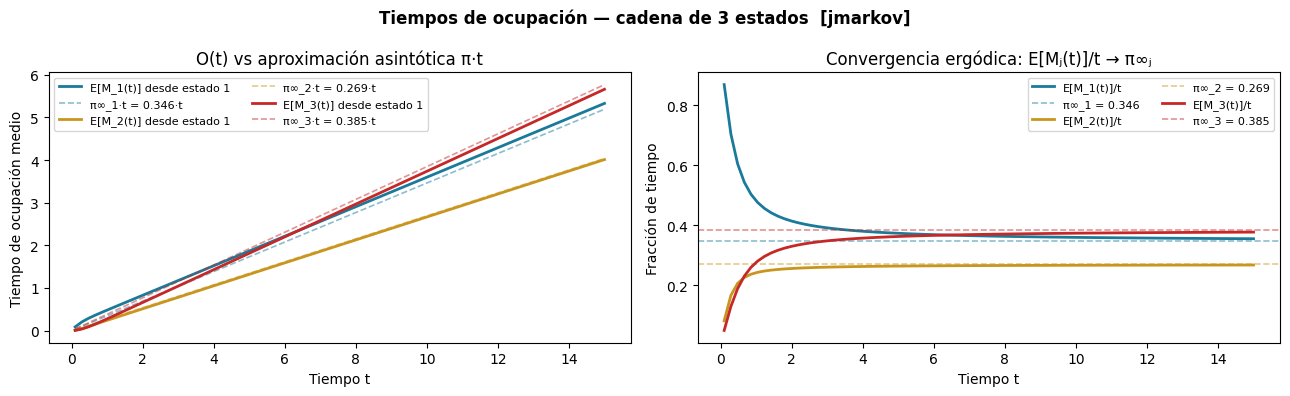

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# ── Gráfica: convergencia al comportamiento asintótico ────────────────
Q3 = np.array([[-3.,  2.,  1.],
               [ 1., -4.,  3.],
               [ 2.,  1., -3.]])
mc3 = ctmc(Q3, np.array(['Estado 1', 'Estado 2', 'Estado 3']))
pi_inf = mc3.steady_state()

t_vals = np.linspace(0.1, 15, 80)   # menos puntos: occupation_time llama uniformización

# occupation_time(t)[i,j] = E[Mⱼ(t) | X(0) = estado i]
# Extraemos la fila 0 (inicio en estado 1)
occ_t = np.array([mc3.occupation_time(t)[0, :] for t in t_vals])  # (n_t, 3)

colores = ['#1A7A9A', '#C8961E', '#C62828']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: tiempo de ocupación E[Mⱼ(t)]
for j in range(3):
    axes[0].plot(t_vals, occ_t[:, j], color=colores[j], lw=2,
                 label=f'E[M_{j+1}(t)] desde estado 1')
    axes[0].plot(t_vals, pi_inf[j] * t_vals, color=colores[j],
                 lw=1.2, ls='--', alpha=0.5, label=f'π∞_{j+1}·t = {pi_inf[j]:.3f}·t')
axes[0].set_xlabel('Tiempo t'); axes[0].set_ylabel('Tiempo de ocupación medio')
axes[0].set_title('O(t) vs aproximación asintótica π·t')
axes[0].legend(fontsize=8, ncol=2)

# Panel derecho: fracción de tiempo (convergencia al equilibrio)
for j in range(3):
    fraccion = occ_t[:, j] / t_vals
    axes[1].plot(t_vals, fraccion, color=colores[j], lw=2,
                 label=f'E[M_{j+1}(t)]/t')
    axes[1].axhline(pi_inf[j], color=colores[j], lw=1.2, ls='--', alpha=0.5,
                    label=f'π∞_{j+1} = {pi_inf[j]:.3f}')
axes[1].set_xlabel('Tiempo t'); axes[1].set_ylabel('Fracción de tiempo')
axes[1].set_title('Convergencia ergódica: E[Mⱼ(t)]/t → π∞ⱼ')
axes[1].legend(fontsize=8, ncol=2)
plt.suptitle('Tiempos de ocupación — cadena de 3 estados  [jmarkov]', fontweight='bold')
plt.tight_layout()
plt.show()


## Ejemplo detallado: sistema componente + respaldo

<div class='defn'>
Sistema con dos variables indicadoras:
- X: componente operativo (X=1) o inactivo (X=0)
- Y: respaldo disponible (Y=1) o no (Y=0)

| Estado | (X,Y) | Descripción |
|--------|-------|-------------|
| 0 | (0,0) | Componente inactivo, sin respaldo |
| 1 | (1,0) | Operativo, sin respaldo |
| 2 | (1,1) | Operativo, con respaldo (modo completo) |

$$Q = \begin{pmatrix} -2 & 2 & 0 \\ 1 & -5 & 4 \\ 0 & 3 & -3 \end{pmatrix}$$
</div>

**Cuatro preguntas:**
1. ¿Cuánto tarda en promedio en alcanzar el modo completo (estado 2)?
2. ¿Cuánto tarda en promedio en caer al estado inactivo (estado 0)?
3. ¿Cuánto tiempo pasa en cada estado antes de llegar al modo completo?
4. ¿Cuánto tiempo pasa en cada estado antes de caer al estado inactivo?

In [12]:
import numpy as np
from jmarkov.ctmc import ctmc
from scipy.linalg import solve, inv

# ── Sistema componente + respaldo ─────────────────────────────────────
Q_cr = np.array([[-2.,  2.,  0.],
                 [ 1., -5.,  4.],
                 [ 0.,  3., -3.]])
estados_cr = np.array(['0:(0,0) Inactivo', '1:(1,0) Operativo', '2:(1,1) Completo'])
mc_cr = ctmc(Q_cr, estados_cr)

# ── Distribución estacionaria ─────────────────────────────────────────
pi_cr = mc_cr.steady_state()
print("Distribución estacionaria:")
for i, e in enumerate(estados_cr):
    print(f"  π∞({e}) = {pi_cr[i]:.4f}  ({pi_cr[i]*100:.1f}%)")

print()
print("═" * 60)
print("  PREGUNTA 1: MFPT al modo completo (A={2}, B={0,1})")
print("═" * 60)
# QB con B={0,1} → submatriz filas/cols 0,1
QB_al2 = Q_cr[:2, :2]
m_al2 = solve(QB_al2, -np.ones(2))
print(f"  m₀₂ = {m_al2[0]:.4f}  (esperado 7/8 = 0.875)")
print(f"  m₁₂ = {m_al2[1]:.4f}  (esperado 3/8 = 0.375)")

# Verificar con jmarkov
fpt_al2 = mc_cr.first_passage_time(2)
print(f"  jmarkov → m₀₂ = {fpt_al2[0,0]:.4f},  m₁₂ = {fpt_al2[1,0]:.4f}  ✓")

print()
print("═" * 60)
print("  PREGUNTA 2: MFPT al estado inactivo (A={0}, B={1,2})")
print("═" * 60)
# QB con B={1,2} → submatriz filas/cols 1,2
QB_al0 = Q_cr[1:, 1:]
m_al0 = solve(QB_al0, -np.ones(2))
print(f"  m₁₀ = {m_al0[0]:.4f}  (esperado 7/3 ≈ 2.333)")
print(f"  m₂₀ = {m_al0[1]:.4f}  (esperado 8/3 ≈ 2.667)")

fpt_al0 = mc_cr.first_passage_time(0)
print(f"  jmarkov → m₁₀ = {fpt_al0[0,0]:.4f},  m₂₀ = {fpt_al0[1,0]:.4f}  ✓")

Distribución estacionaria:
  π∞(0:(0,0) Inactivo) = 0.1765  (17.6%)
  π∞(1:(1,0) Operativo) = 0.3529  (35.3%)
  π∞(2:(1,1) Completo) = 0.4706  (47.1%)

════════════════════════════════════════════════════════════
  PREGUNTA 1: MFPT al modo completo (A={2}, B={0,1})
════════════════════════════════════════════════════════════
  m₀₂ = 0.8750  (esperado 7/8 = 0.875)
  m₁₂ = 0.3750  (esperado 3/8 = 0.375)
  jmarkov → m₀₂ = 0.8750,  m₁₂ = 0.3750  ✓

════════════════════════════════════════════════════════════
  PREGUNTA 2: MFPT al estado inactivo (A={0}, B={1,2})
════════════════════════════════════════════════════════════
  m₁₀ = 2.3333  (esperado 7/3 ≈ 2.333)
  m₂₀ = 2.6667  (esperado 8/3 ≈ 2.667)
  jmarkov → m₁₀ = 2.3333,  m₂₀ = 2.6667  ✓


In [13]:
import numpy as np
from jmarkov.ctmc import ctmc
from scipy.linalg import inv

Q_cr = np.array([[-2.,  2.,  0.],
                 [ 1., -5.,  4.],
                 [ 0.,  3., -3.]])

print("═" * 65)
print("  PREGUNTA 3: Tiempos de ocupación antes de llegar al estado 2")
print("  A={2}, B={0,1}")
print("═" * 65)
QB_al2 = Q_cr[:2, :2]
M3 = -inv(QB_al2)   # ℳ = −QB⁻¹
print(f"\nℳ = −QB⁻¹ =\n{M3.round(4)}")
print()
print(f"{'Desde':>8} | {'μ(en estado 0)':>16} | {'μ(en estado 1)':>16} | {'MFPT m_i2':>12}")
print("-" * 60)
for i in range(2):
    print(f" i={i:>5} | {M3[i,0]:>16.4f} | {M3[i,1]:>16.4f} | {M3[i].sum():>12.4f}")

print()
print("═" * 65)
print("  PREGUNTA 4: Tiempos de ocupación antes de caer al estado 0")
print("  A={0}, B={1,2}")
print("═" * 65)
QB_al0 = Q_cr[1:, 1:]
M4 = -inv(QB_al0)
print(f"\nℳ = −QB⁻¹ =\n{M4.round(4)}")
print()
print(f"{'Desde':>8} | {'μ(en estado 1)':>16} | {'μ(en estado 2)':>16} | {'MFPT m_i0':>12}")
print("-" * 60)
for i, idx in enumerate([1, 2]):
    print(f" i={idx:>5} | {M4[i,0]:>16.4f} | {M4[i,1]:>16.4f} | {M4[i].sum():>12.4f}")

print()
print("Observación notable: μ₁₁ = μ₂₁ = 1 (desde ambos estados, se pasa")
print("exactamente 1 u.t. en el estado 1 antes de caer al estado 0).")
print("Razón: desde el estado 2 se pasa NECESARIAMENTE por el estado 1")
print("antes de llegar a 0; al llegar a 1 se 'reinicia' por Markov.")

═════════════════════════════════════════════════════════════════
  PREGUNTA 3: Tiempos de ocupación antes de llegar al estado 2
  A={2}, B={0,1}
═════════════════════════════════════════════════════════════════

ℳ = −QB⁻¹ =
[[0.625 0.25 ]
 [0.125 0.25 ]]

   Desde |   μ(en estado 0) |   μ(en estado 1) |    MFPT m_i2
------------------------------------------------------------
 i=    0 |           0.6250 |           0.2500 |       0.8750
 i=    1 |           0.1250 |           0.2500 |       0.3750

═════════════════════════════════════════════════════════════════
  PREGUNTA 4: Tiempos de ocupación antes de caer al estado 0
  A={0}, B={1,2}
═════════════════════════════════════════════════════════════════

ℳ = −QB⁻¹ =
[[1.     1.3333]
 [1.     1.6667]]

   Desde |   μ(en estado 1) |   μ(en estado 2) |    MFPT m_i0
------------------------------------------------------------
 i=    1 |           1.0000 |           1.3333 |       2.3333
 i=    2 |           1.0000 |           1.6667 |   

## Ejercicio: Costo acumulado hasta la falla total

<div class='defn'>
El sistema incurre un costo por unidad de tiempo de:
- **\$5** cuando está en el estado 1 (operativo sin respaldo)
- **\$2** cuando está en el estado 2 (modo completo)

Sea C el costo total acumulado desde que el sistema arranca en el **estado 2** hasta que cae al **estado 0** (falla total).

Calcule 𝔼[C].
</div>

**Solución:** el costo total es una función lineal de los tiempos de ocupación:

$$C = 5\,M_1^{(\{0\})} + 2\,M_2^{(\{0\})}$$

Por linealidad de la esperanza (con estado inicial i=2):

$$\mathbb{E}_2[C] = 5\,\mu_{21} + 2\,\mu_{22} = 5 \cdot 1 + 2 \cdot \frac{5}{3} = 5 + \frac{10}{3} = \frac{25}{3} \approx \$8.33$$

<div class='resultado'>
El costo esperado hasta la falla total, partiendo del modo completo, es <strong>\$25/3 ≈ \$8.33</strong>.
</div>

In [14]:
import numpy as np
from jmarkov.ctmc import ctmc
from scipy.linalg import inv

Q_cr = np.array([[-2.,  2.,  0.],
                 [ 1., -5.,  4.],
                 [ 0.,  3., -3.]])
mc_cr = ctmc(Q_cr, np.array(['0:Inactivo', '1:Operativo', '2:Completo']))

# Tiempos de ocupación antes de caer al estado 0
QB_al0 = Q_cr[1:, 1:]
M4 = -inv(QB_al0)  # M4[i,j] = μ_{i+1, j+1} con B={1,2}

# ── Ejercicio 1: Costo esperado ───────────────────────────────────────
costo_1 = 5.0   # $/u.t. en estado 1
costo_2 = 2.0   # $/u.t. en estado 2

# Estado inicial i=2 → fila 1 de M4 (índice 1 en B={1,2})
mu_21 = M4[1, 0]   # μ₂₁ = E[tiempo en estado 1 | inicio en 2]
mu_22 = M4[1, 1]   # μ₂₂ = E[tiempo en estado 2 | inicio en 2]

E_costo = costo_1 * mu_21 + costo_2 * mu_22
print("═" * 55)
print("  Ejercicio: Costo acumulado hasta falla total")
print("  (inicio en estado 2 = modo completo)")
print("═" * 55)
print(f"  μ₂₁ = {mu_21:.4f}  (tiempo esperado en estado 1)")
print(f"  μ₂₂ = {mu_22:.4f}  (tiempo esperado en estado 2)")
print(f"\n  E[C] = 5·μ₂₁ + 2·μ₂₂")
print(f"       = 5·{mu_21:.4f} + 2·{mu_22:.4f}")
print(f"       = {5*mu_21:.4f} + {2*mu_22:.4f}")
print(f"       = {E_costo:.4f}  (exacto: 25/3 = {25/3:.4f})")

# ── Ejercicio 2: Número esperado de visitas ───────────────────────────
print()
print("═" * 55)
print("  Ejercicio: Número esperado de visitas al estado 1")
print("  antes de llegar al modo completo (estado 2)")
print("  (inicio en estado 0)")
print("═" * 55)
# A={2}, B={0,1}: QB_al2 ya calculado
QB_al2 = Q_cr[:2, :2]
M3 = -inv(QB_al2)
q1 = abs(Q_cr[1, 1])   # tasa total de salida del estado 1
q0 = abs(Q_cr[0, 0])   # tasa total de salida del estado 0
mu_01 = M3[0, 1]        # μ₀₁ = E[tiempo en estado 1 | inicio en 0]
mu_00 = M3[0, 0]        # μ₀₀ = E[tiempo en estado 0 | inicio en 0]

E_N1 = q1 * mu_01   # E[visitas al estado 1 desde 0]
E_N0 = q0 * mu_00   # E[visitas al estado 0 desde 0]
print(f"  q₁ = {q1}, μ₀₁ = {mu_01:.4f}")
print(f"  E₀[N₁] = q₁·μ₀₁ = {q1}·{mu_01:.4f} = {E_N1:.4f}  (exacto: 5/4 = {5/4})")
print(f"  E₀[N₀] = q₀·μ₀₀ = {q0}·{mu_00:.4f} = {E_N0:.4f}  (exacto: 5/4 = {5/4})")

# ── Ejercicio 3: Distribución estacionaria y tiempos de retorno ───────
print()
print("═" * 55)
print("  Distribución estacionaria y tiempos de retorno")
print("═" * 55)
pi_cr = mc_cr.steady_state()
q_vec = np.abs(np.diag(Q_cr))
print(f"  π∞ = {pi_cr.round(4)}")
print(f"  (exacto: π₀=3/17={3/17:.4f}, π₁=6/17={6/17:.4f}, π₂=8/17={8/17:.4f})")
print()
for j in range(3):
    t_retorno = 1 / (pi_cr[j] * q_vec[j])
    print(f"  E[T_retorno | estado {j}] = 1/(π{j}·q{j}) = "
          f"1/({pi_cr[j]:.4f}·{q_vec[j]:.1f}) = {t_retorno:.4f} u.t.")

═══════════════════════════════════════════════════════
  Ejercicio: Costo acumulado hasta falla total
  (inicio en estado 2 = modo completo)
═══════════════════════════════════════════════════════
  μ₂₁ = 1.0000  (tiempo esperado en estado 1)
  μ₂₂ = 1.6667  (tiempo esperado en estado 2)

  E[C] = 5·μ₂₁ + 2·μ₂₂
       = 5·1.0000 + 2·1.6667
       = 5.0000 + 3.3333
       = 8.3333  (exacto: 25/3 = 8.3333)

═══════════════════════════════════════════════════════
  Ejercicio: Número esperado de visitas al estado 1
  antes de llegar al modo completo (estado 2)
  (inicio en estado 0)
═══════════════════════════════════════════════════════
  q₁ = 5.0, μ₀₁ = 0.2500
  E₀[N₁] = q₁·μ₀₁ = 5.0·0.2500 = 1.2500  (exacto: 5/4 = 1.25)
  E₀[N₀] = q₀·μ₀₀ = 2.0·0.6250 = 1.2500  (exacto: 5/4 = 1.25)

═══════════════════════════════════════════════════════
  Distribución estacionaria y tiempos de retorno
═══════════════════════════════════════════════════════
  π∞ = [0.1765 0.3529 0.4706]
  (exacto: π₀=3/

## Caso aplicado: sistema de degradación

<div class='defn'>
Un componente industrial evoluciona entre tres estados:

| Estado | Descripción | Costo/hora |
|--------|-------------|------------|
| 0 — Normal | Operación sin restricciones | $0 |
| 1 — Degradado | Operación reducida | $3 |
| 2 — Fallo | Sistema detenido | $10 |

$$Q = \begin{pmatrix} -0.4 & 0.3 & 0.1 \\ 1.0 & -1.4 & 0.4 \\ 0.0 & 0.8 & -0.8 \end{pmatrix}$$
</div>

**Preguntas:**
- ¿Cuánto tiempo tarda en promedio en llegar al estado Fallo desde cada estado?
- ¿Cuánto tiempo pasa en cada estado antes del primer fallo?
- ¿Cuál es el costo esperado acumulado hasta el primer fallo?

════════════════════════════════════════════════════════════
  Sistema de degradación — Análisis de tiempos
════════════════════════════════════════════════════════════

MFPT al estado Fallo:
  Desde Normal      : 6.5385 h
  Desde Degradado   : 5.3846 h

Tiempos de ocupación antes del primer fallo (ℳ = −QB⁻¹):
       Desde |   en Normal (h) |   en Degradado (h) |   MFPT (h)
  ----------------------------------------------------------
      Normal |          5.3846 |             1.1538 |     6.5385
   Degradado |          3.8462 |             1.5385 |     5.3846

Costo esperado acumulado hasta el primer fallo:
  E[C | inicio en Normal    ] = 0.0·5.3846 + 3.0·1.1538 = $3.4615
  E[C | inicio en Degradado ] = 0.0·3.8462 + 3.0·1.5385 = $4.6154

Distribución estacionaria: {np.str_('Normal'): np.float64(0.5797), np.str_('Degradado'): np.float64(0.2319), np.str_('Fallo'): np.float64(0.1884)}
Disponibilidad (Normal+Degradado) = 81.2%


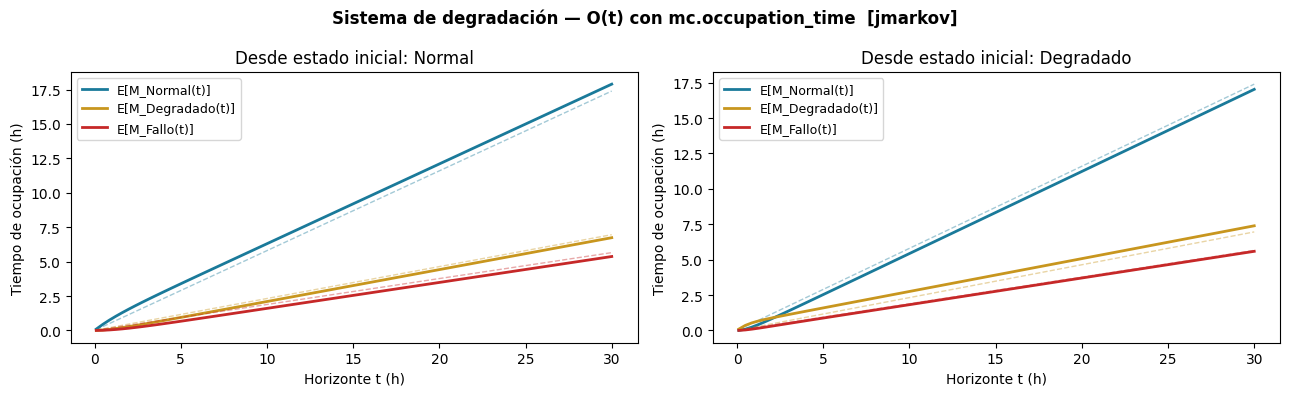

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc
from scipy.linalg import inv

# ── Sistema de degradación ────────────────────────────────────────────
Q_deg = np.array([[-0.4,  0.3,  0.1],
                  [ 1.0, -1.4,  0.4],
                  [ 0.0,  0.8, -0.8]])
estados_deg = np.array(['Normal', 'Degradado', 'Fallo'])
mc_deg = ctmc(Q_deg, estados_deg)

# ── MFPT al fallo (A={Fallo}=índice 2, B={Normal,Degradado}={0,1}) ──
print("═" * 60)
print("  Sistema de degradación — Análisis de tiempos")
print("═" * 60)

fpt_fallo = mc_deg.first_passage_time(2)
print("\nMFPT al estado Fallo:")
for i in range(2):
    print(f"  Desde {estados_deg[i]:12s}: {fpt_fallo[i, 0]:.4f} h")

# ── Tiempos de ocupación hasta el primer fallo: ℳ = −QB⁻¹ ────────────
QB_deg = Q_deg[:2, :2]
M_deg = -inv(QB_deg)

print("\nTiempos de ocupación antes del primer fallo (ℳ = −QB⁻¹):")
print(f"  {'Desde':>10} | {'en Normal (h)':>15} | {'en Degradado (h)':>18} | {'MFPT (h)':>10}")
print("  " + "-" * 58)
for i, e in enumerate(estados_deg[:2]):
    print(f"  {e:>10} | {M_deg[i,0]:>15.4f} | {M_deg[i,1]:>18.4f} | {M_deg[i].sum():>10.4f}")

# ── Costo esperado hasta el primer fallo ─────────────────────────────
costos = np.array([0.0, 3.0])   # $/h en Normal y Degradado
print("\nCosto esperado acumulado hasta el primer fallo:")
for i, e in enumerate(estados_deg[:2]):
    E_C = costos @ M_deg[i, :]
    print(f"  E[C | inicio en {e:10s}] = {costos[0]}·{M_deg[i,0]:.4f} + {costos[1]}·{M_deg[i,1]:.4f} = ${E_C:.4f}")

# ── Distribución estacionaria ─────────────────────────────────────────
pi_deg = mc_deg.steady_state()
print(f"\nDistribución estacionaria: {dict(zip(estados_deg, pi_deg.round(4)))}")
print(f"Disponibilidad (Normal+Degradado) = {(pi_deg[0]+pi_deg[1])*100:.1f}%")

# ── Visualización con mc_deg.occupation_time(t) ──────────────────────
# occupation_time(t)[i,j] = E[Mⱼ(t) | X(0) = estado i]
t_vals = np.linspace(0.1, 30, 80)
# Precalcular para los dos estados iniciales de interés (Normal=0, Degradado=1)
occ_data = {i: np.array([mc_deg.occupation_time(t)[i, :] for t in t_vals])
            for i in range(2)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores_deg = ['#1A7A9A', '#C8961E', '#C62828']
for idx_ini, (e_ini, ax) in enumerate(zip(estados_deg[:2], axes)):
    for j, (e_j, col) in enumerate(zip(estados_deg, colores_deg)):
        ax.plot(t_vals, occ_data[idx_ini][:, j], color=col, lw=2,
                label=f'E[M_{e_j}(t)]')
        ax.plot(t_vals, pi_deg[j] * t_vals, color=col, lw=1, ls='--', alpha=0.4)
    ax.set_xlabel('Horizonte t (h)'); ax.set_ylabel('Tiempo de ocupación (h)')
    ax.set_title(f'Desde estado inicial: {e_ini}')
    ax.legend(fontsize=9)
plt.suptitle('Sistema de degradación — O(t) con mc.occupation_time  [jmarkov]',
             fontweight='bold')
plt.tight_layout()
plt.show()


## Resumen de fórmulas clave

Sea {X(t)} una CTMC irreducible con generador Q sobre S = {1,…,N}. Sea A ⊊ S, B = S \ A, QB la submatriz de Q en B.

| # | Cantidad | Fórmula |
|---|----------|---------|
| **1** | MFPT: **m**ᵢA = 𝔼ᵢ[TA] | QB **m** = −**1** → **m** = −QB⁻¹ **1** |
| **2** | Ocupación horizonte fijo | 𝒪(t) = ∫₀ᵗ e^{Qs} ds |
| **3** | Ocupación hasta 1ª pasada | QB ℳ = −I → ℳ = −QB⁻¹ |
| **4** | MFPT desde ocupación | **m** = ℳ **1** |
| **5** | Número esperado de visitas | 𝔼ᵢ[Nⱼ] = qⱼ · μᵢⱼ |
| **6** | Ergodismo (t → ∞) | 𝔼ᵢ[Mⱼ(t)] / t → πⱼ |
| **7** | Tiempo de retorno | 𝔼ⱼ[Tⱼ] = 1 / (πⱼ · qⱼ) |

<div class='nota'>
<strong>Clave computacional:</strong> la matriz −QB⁻¹ contiene toda la información:

- Sus entradas son los tiempos medios de ocupación hasta la primera pasada (μᵢⱼ)
- Su suma por filas da los MFPT (**m**)
- Multiplicando por qⱼ se obtiene el número esperado de visitas
</div>

## Conclusiones

- El **MFPT** responde "¿cuándo llega el sistema a un estado objetivo?": QB **m** = −**1**.
- Los **tiempos de ocupación** responden "¿cuánto tiempo pasa el sistema en cada estado?":
  - Horizonte fijo t: 𝒪(t) = ∫₀ᵗ e^{Qs} ds (requiere exponencial matricial)
  - Hasta 1ª pasada: ℳ = −QB⁻¹ (solo álgebra lineal)
- La **conexión MFPT ↔ ocupación**: **m** = ℳ **1** (el MFPT es la suma de todos los tiempos de ocupación).
- El **teorema ergódico** garantiza que para t grande, la fracción de tiempo en el estado j converge a πⱼ, independientemente del estado inicial.
- Los tiempos de ocupación permiten calcular **costos acumulados** y **número de visitas** antes de un evento de interés.
